#EDA and claening
1. We check general information about datframe, quantities, types of variable, nulls, columns name, etc

In [22]:
#GENERAL OVERVIEW OF DATA SET
import pandas as pd
df_02=pd.read_parquet('../data/raw_data.parquet')
df_02.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 536321 entries, 0 to 536320
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id_transaccion  536321 non-null  object 
 1   id_vehiculo     536321 non-null  int64  
 2   id_ubicacion    536321 non-null  int64  
 3   id_cliente      536321 non-null  int64  
 4   fecha           536321 non-null  object 
 5   unidades        536321 non-null  int64  
 6   venta_bruta_sn  536321 non-null  float64
 7   modelo          536321 non-null  object 
 8   marcas_cl       536321 non-null  object 
dtypes: float64(1), int64(4), object(4)
memory usage: 36.8+ MB


2. Fix or change some variables in order to get them ready for analysis

In [23]:
#CHANGE DATE FORMAT 
df_02['fecha'] = pd.to_datetime(df_02['fecha'])
df_02['venta_unitaria'] = df_02['venta_bruta_sn'] / df_02['unidades']
df_02.head(15)

,id_transaccion,id_vehiculo,id_ubicacion,id_cliente,fecha,unidades,venta_bruta_sn,modelo,marcas_cl,venta_unitaria
0,ST-2000000,1,1,4446,2024-11-04,1,347951.0,5008,Peugeot,347951.0
1,ST-2000001,2,2,5967,2025-10-20,1,808947.0,1500,RAM,808947.0
2,ST-2000002,3,3,1084,2023-12-24,1,533672.0,Pulse,Fiat,533672.0
3,ST-2000003,4,4,12388,2023-07-27,1,493390.0,Grand Cherokee,Jeep,493390.0
4,ST-2000004,5,2,2022,2025-10-25,2,1698334.0,ProMaster,RAM,849167.0
5,ST-2000005,6,5,2466,2024-01-25,1,902230.0,Ducato,Fiat,902230.0
6,ST-2000006,7,5,2355,2023-01-09,1,927566.0,ProMaster,RAM,927566.0
7,ST-2000007,8,6,14630,2025-09-07,1,359892.0,Argo,Fiat,359892.0
8,ST-2000008,5,2,1228,2023-04-21,1,570192.0,ProMaster,RAM,570192.0
9,ST-2000009,5,3,1316,2022-05-16,1,826663.0,ProMaster,RAM,826663.0


3. We check a general statistical sumary of dataframe, in order to get an overview about basic SPC.

In [24]:
#STATISTICAL SUMMARY
df_02.describe()

,id_vehiculo,id_ubicacion,id_cliente,fecha,unidades,venta_bruta_sn,venta_unitaria
count,536321.000000,536321.000000,536321.000000,536321,536321.000000,5.363210e+05,5.363210e+05
mean,13.121017,3.803019,7714.475374,2024-01-30 12:14:10.997816832,1.035867,6.832228e+05,6.600197e+05
min,1.000000,1.000000,1.000000,2022-01-01 00:00:00,1.000000,3.400000e+05,1.334786e+05
25%,5.000000,2.000000,3860.000000,2023-01-02 00:00:00,1.000000,5.040940e+05,5.004410e+05
50%,13.000000,4.000000,7706.000000,2024-01-02 00:00:00,1.000000,6.673930e+05,6.610800e+05
75%,19.000000,5.000000,11569.000000,2024-12-28 00:00:00,1.000000,8.111850e+05,8.026380e+05
max,46.000000,7.000000,15432.000000,2025-12-28 00:00:00,5.000000,8.993305e+06,5.025246e+06
std,9.076756,1.566978,4454.410569,NaN,0.311565,2.988369e+05,2.021434e+05


4. Otlier detection. As we can see we are going to handle brands going through luxury to cheaper, so we need to implement central trend metrics according to this.
- MAD (Median Absolute Devistion) instead of mean to classify outliers by brand group.
- Robust Z-score with 0.6745 as normalization factor will be used on each brand group (sigma~MAD/0.6745)
- Function allows to apply outlier detection separately for each brand group, instead of across the whole dataset.
- Even on each brand could have gaps between models, for this reason we choose MAD instead sigma method.

In [25]:
import numpy as np

def detect_robust_outliers(group):
    mediana = group['venta_unitaria'].median()
    # MAD calculation
    mad = np.median(np.abs(group['venta_unitaria'] - mediana))
    
    # In case values are the same
    if mad == 0:
        return pd.Series(False, index=group.index)
    
    # Robust Z-Score calculation
    z_robust = 0.6745 * (group['venta_unitaria'] - mediana) / mad
    return np.abs(z_robust) > 3.5

df_1 = df_02.copy()
# Applying by brand groups
df_1['outliers'] = df_02.groupby('marcas_cl', group_keys=False).apply(detect_robust_outliers)

# Sumary by brand
outliers_summary = df_1.groupby('marcas_cl')['outliers'].sum().reset_index()
print(outliers_summary)
orden_marcas = outliers_summary['marcas_cl'].tolist()

    marcas_cl  outliers
0  Alfa Romeo         3
1       Dodge         0
2        Fiat         0
3        Jeep         1
4     Peugeot         0
5         RAM         0


5. We get some graphs in order to understand and have a clear view of outliers. 

/home/joe/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/joe/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


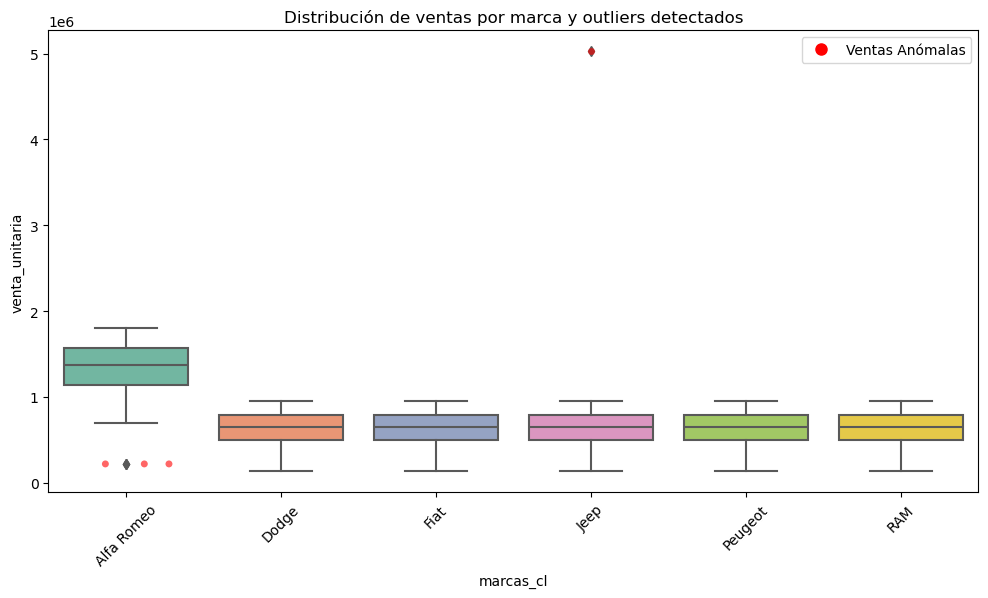

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

plt.figure(figsize=(12, 6))
# Usamos escala logarítmica si los precios entre RAM y FIAT varían en órdenes de magnitud
sns.boxplot(x='marcas_cl', y='venta_unitaria', data=df_1, order=orden_marcas, palette="Set2")

#Highlight in red the outliers
anomalos = df_1[df_1['outliers']]
sns.stripplot(data=anomalos,x='marcas_cl',y='venta_unitaria',hue='outliers',order=orden_marcas, palette={True: 'red', False: 'skyblue'}, alpha=0.6,legend=False)

punto_alerta = mlines.Line2D(
    [], [],               
    color='red', 
    marker='o',           
    linestyle='None',    
    markersize=8,
    label='Ventas Anómalas')

plt.title('Distribución de ventas por marca y outliers detectados')
plt.xticks(rotation=45)
plt.legend(handles=[punto_alerta])
plt.savefig('../graphs/outliers.png', dpi=300)
plt.show()

6. We impute outliers, taking median of subgroups of same brand, model and quantity.

In [27]:
import pandas as pd
import numpy as np

df_imputed = df_1.copy()

columnas_grupo = ['marcas_cl', 'modelo', 'unidades']

df_imputed['precio_referencia'] = df_imputed.groupby(columnas_grupo)['venta_unitaria'].transform('median')

#Replacement, if outlier is found, it will be replaced by reference price, otherwise price stays.
df_imputed['venta_unitaria'] = np.where(df_imputed['outliers'] == True, df_imputed['precio_referencia'], df_imputed['venta_unitaria'])
df_imputed['venta_bruta_sn'] = np.where(df_imputed['outliers'] == True,df_imputed['unidades'] * df_imputed['precio_referencia'] , df_imputed['venta_bruta_sn'])
#Check outliers match
outliers_sin_referencia = df_imputed[df_imputed['outliers'] & df_imputed['precio_referencia'].isna()]

if not outliers_sin_referencia.empty:
    print(f"❌ Atención: {len(outliers_sin_referencia)} outliers no tienen otros modelos iguales para comparar.")
else:
    print("✅ Todos los valores atípicos han sido corregidos con la mediana de sus grupos correspondientes.")

# Drop temporary columns
df_imputed.drop(columns=['precio_referencia'], inplace=True)

✅ Todos los valores atípicos han sido corregidos con la mediana de sus grupos correspondientes.


7. Export dataframe to clean_data.parquet

In [28]:
df_imputed = df_imputed.loc[:, ~df_imputed.columns.duplicated()] #Drop duplicated columns if exist
df_imputed.to_parquet('../data/clean_data.parquet', index=False)
print("✅ Extracion completa")

✅ Extracion completa
